# V4 Results Analysis

GSM-Infinity RL v4 experiments with skewed pretrained model (op=2-10)

In [11]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
os.chdir('/fast/pmayilvahanan/Interplay-LM-Reasoning/analyze/')
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

In [12]:
# Config
RESULTS_DIR = Path("../results/gsm_infinity_rl_v4")
PASS_K_VALUES = [1, 2, 4, 8, 16, 32, 64, 128]

# Difficulty groups (by num_ops)
DIFFICULTY_GROUPS = {
    "ID (op=2-10)": list(range(2, 11)),
    "OOD-mid (op=11-14)": list(range(11, 15)),
    "OOD-hard (op=15-20)": list(range(15, 21)),
}

# Display names for runs
DISPLAY_NAMES = {
    "base_model_eval_pass128": "Base (skewed)",
    "grpo_edge_v4": "GRPO (Edge)",
    "dr_gspo_edge_v4": "DR-GSPO (Edge)",
    "dr_gspo_eta005_edge_v4": "DR-GSPO-eta0.05 (Edge)",
    "dr_gspo_eta01_edge_v4": "DR-GSPO-eta0.1 (Edge)",
    "dr_gspo_eta05_edge_v4": "DR-GSPO-eta0.5 (Edge)",
}

In [13]:
def load_metrics(run_name):
    """Load metrics for a run."""
    run_dir = RESULTS_DIR / run_name
    
    # For training runs, prefer checkpoint eval metrics over root-level metrics.jsonl
    # (root-level metrics.jsonl may be stale/copied)
    iter_file = run_dir / "latest_checkpointed_iteration.txt"
    if iter_file.exists():
        step = iter_file.read_text().strip()
        eval_metrics = run_dir / f"global_step_{step}" / "eval_pass128" / "metrics.jsonl"
        if eval_metrics.exists():
            with open(eval_metrics) as f:
                return json.loads(f.readline())["metrics"]
    
    # Fall back to root-level metrics.jsonl (for base model evals)
    metrics_file = run_dir / "metrics.jsonl"
    if metrics_file.exists():
        with open(metrics_file) as f:
            return json.loads(f.readline())["metrics"]
    
    return None


def extract_pass_k(metrics, difficulty_ops, k):
    """Extract pass@k for a given difficulty group."""
    key_pattern = f"val-aux/difficulty-5B/{{}}/reward/pass@{k}"
    vals = []
    for op in difficulty_ops:
        key = key_pattern.format(op)
        if key in metrics:
            vals.append(metrics[key])
    return np.mean(vals) if vals else 0.0


def get_run_data(run_name):
    """Get all pass@k values for a run across difficulty groups."""
    metrics = load_metrics(run_name)
    if metrics is None:
        return None
    
    data = {}
    for group_name, ops in DIFFICULTY_GROUPS.items():
        data[group_name] = {k: extract_pass_k(metrics, ops, k) for k in PASS_K_VALUES}
    return data

In [14]:
# List available v4 runs
print("Available v4 runs:")
for d in sorted(RESULTS_DIR.iterdir()):
    if d.is_dir():
        iter_file = d / "latest_checkpointed_iteration.txt"
        metrics_file = d / "metrics.jsonl"
        if iter_file.exists():
            step = iter_file.read_text().strip()
            eval_dir = d / f"global_step_{step}" / "eval_pass128"
            status = "EVAL_COMPLETE" if (eval_dir / "metrics.jsonl").exists() else "EVAL_MISSING"
            print(f"  {d.name}: step={step}, {status}")
        elif metrics_file.exists():
            print(f"  {d.name}: COMPLETE (base model eval)")

Available v4 runs:
  base_model_eval_pass128: COMPLETE (base model eval)
  dr_gspo_edge_v4: step=388, EVAL_COMPLETE
  dr_gspo_eta005_edge_v4: step=388, EVAL_COMPLETE
  dr_gspo_eta01_edge_v4: step=388, EVAL_COMPLETE
  dr_gspo_eta05_edge_v4: step=388, EVAL_COMPLETE
  dr_gspo_eta1_edge_v4: step=388, EVAL_MISSING
  grpo_dpg_eta05_edge_v4: step=388, EVAL_COMPLETE
  grpo_dpg_eta128_edge_v4: step=388, EVAL_MISSING
  grpo_dpg_eta1_edge_v4: step=388, EVAL_COMPLETE
  grpo_dpg_eta2_edge_v4: step=390, EVAL_MISSING
  grpo_dpg_eta32_edge_v4: step=310, EVAL_MISSING
  grpo_dpg_eta4_edge_v4: step=70, EVAL_MISSING
  grpo_dpg_eta8_edge_v4: step=388, EVAL_COMPLETE
  grpo_edge_v4: step=388, EVAL_COMPLETE
  grpo_hard_v4: step=386, EVAL_COMPLETE
  grpo_id_v4: step=388, EVAL_COMPLETE
  grpo_mixed_v4: step=388, EVAL_COMPLETE
  grpo_uniform_v4: step=388, EVAL_COMPLETE
  mgpo_uniform_v4_lambda2: step=388, EVAL_COMPLETE
  mgpo_uniform_v4_lambda4: step=388, EVAL_COMPLETE
  mgpo_uniform_v4_lambda6: step=388, EVAL_C

In [15]:
# Load all v4 data
V4_RUNS = [
    "base_model_eval_pass128",
    "grpo_edge_v4",
    "dr_gspo_edge_v4",
    "dr_gspo_eta005_edge_v4",
    "dr_gspo_eta01_edge_v4",
    "dr_gspo_eta05_edge_v4",
]

v4_data = {}
for run in V4_RUNS:
    data = get_run_data(run)
    if data:
        v4_data[run] = data
        print(f"Loaded: {run}")
    else:
        print(f"Missing: {run}")

print(f"\nTotal runs loaded: {len(v4_data)}")

Loaded: base_model_eval_pass128
Loaded: grpo_edge_v4
Loaded: dr_gspo_edge_v4
Loaded: dr_gspo_eta005_edge_v4
Loaded: dr_gspo_eta01_edge_v4
Loaded: dr_gspo_eta05_edge_v4

Total runs loaded: 6


In [16]:
# Summary table
def summary_table(runs, data):
    rows = []
    for run in runs:
        if run not in data:
            continue
        row = {"Run": DISPLAY_NAMES.get(run, run)}
        for group in DIFFICULTY_GROUPS.keys():
            row[f"{group} pass@1"] = f"{data[run][group][1]*100:.1f}"
            row[f"{group} pass@128"] = f"{data[run][group][128]*100:.1f}"
        rows.append(row)
    return pd.DataFrame(rows)

summary_table(V4_RUNS, v4_data)

,Run,ID (op=2-10) pass@1,ID (op=2-10) pass@128,OOD-mid (op=11-14) pass@1,OOD-mid (op=11-14) pass@128,OOD-hard (op=15-20) pass@1,OOD-hard (op=15-20) pass@128
0,Base (skewed),85.5,99.3,22.3,49.4,0.0,0.0
1,GRPO (Edge),80.5,96.5,49.0,85.7,4.8,16.6
2,DR-GSPO (Edge),78.2,96.5,49.1,85.3,5.4,19.3
3,DR-GSPO-eta0.05 (Edge),79.3,97.4,45.0,82.6,3.0,11.9
4,DR-GSPO-eta0.1 (Edge),78.9,97.3,47.8,85.5,4.5,17.0
5,DR-GSPO-eta0.5 (Edge),79.9,96.6,48.9,85.1,5.8,20.2


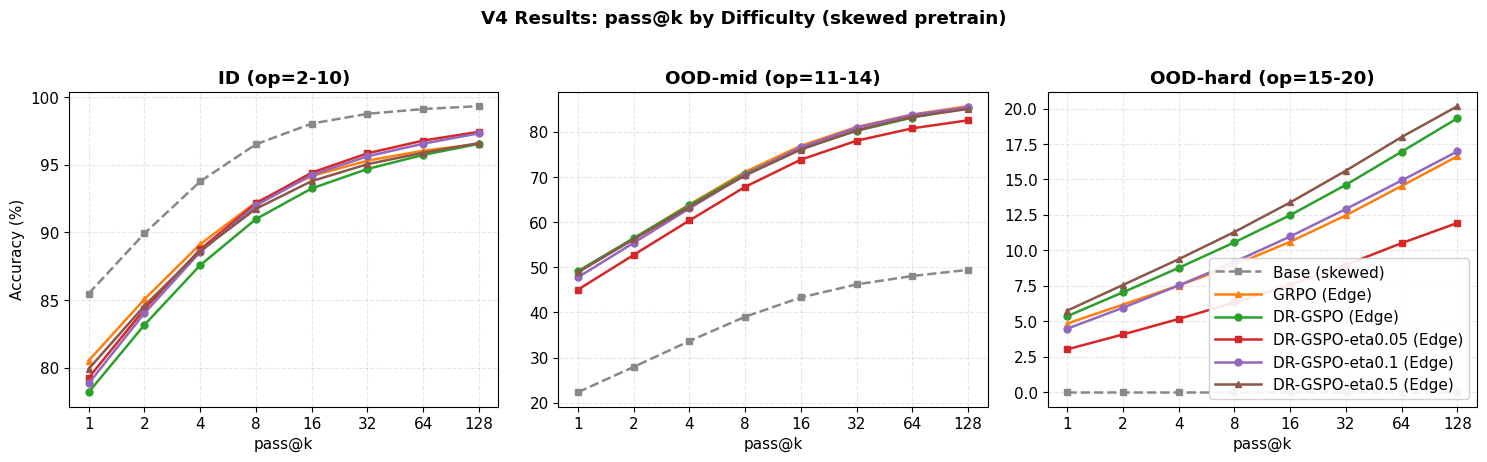

In [17]:
# Plot: Methods comparison (1x3 grid for all difficulty groups)
runs_to_plot = {
    "Base (skewed)": "base_model_eval_pass128",
    "GRPO (Edge)": "grpo_edge_v4",
    "DR-GSPO (Edge)": "dr_gspo_edge_v4",
    "DR-GSPO-eta0.05 (Edge)": "dr_gspo_eta005_edge_v4",
    "DR-GSPO-eta0.1 (Edge)": "dr_gspo_eta01_edge_v4",
    "DR-GSPO-eta0.5 (Edge)": "dr_gspo_eta05_edge_v4",
}

colors = {
    "Base (skewed)": "#888888",
    "GRPO (Edge)": "#ff7f0e",
    "DR-GSPO (Edge)": "#2ca02c",
    "DR-GSPO-eta0.05 (Edge)": "#d62728",
    "DR-GSPO-eta0.1 (Edge)": "#9467bd",
    "DR-GSPO-eta0.5 (Edge)": "#8c564b",
}
markers = {
    "Base (skewed)": "s",
    "GRPO (Edge)": "^",
    "DR-GSPO (Edge)": "o",
    "DR-GSPO-eta0.05 (Edge)": "s",
    "DR-GSPO-eta0.1 (Edge)": "o",
    "DR-GSPO-eta0.5 (Edge)": "^",
}
linestyles = {
    "Base (skewed)": "--",
    "GRPO (Edge)": "-",
    "DR-GSPO (Edge)": "-",
    "DR-GSPO-eta0.05 (Edge)": "-",
    "DR-GSPO-eta0.1 (Edge)": "-",
    "DR-GSPO-eta0.5 (Edge)": "-",
}

groups = ["ID (op=2-10)", "OOD-mid (op=11-14)", "OOD-hard (op=15-20)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

for ax_idx, group in enumerate(groups):
    ax = axes[ax_idx]
    for label, run_name in runs_to_plot.items():
        if run_name not in v4_data:
            continue
        y = [v4_data[run_name][group][k] * 100 for k in PASS_K_VALUES]
        ax.plot(
            range(len(PASS_K_VALUES)), y,
            marker=markers[label], markersize=5, linewidth=1.8,
            color=colors[label], linestyle=linestyles[label],
            label=label,
        )
    ax.set_title(group, fontweight="bold")
    ax.set_xticks(range(len(PASS_K_VALUES)))
    ax.set_xticklabels([str(k) for k in PASS_K_VALUES])
    ax.set_xlabel("pass@k")
    ax.grid(True, alpha=0.3, linestyle="--")

axes[0].set_ylabel("Accuracy (%)")
axes[2].legend(loc="lower right", framealpha=0.9, handlelength=3.0)
fig.suptitle("V4 Results: pass@k by Difficulty (skewed pretrain)", fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig("figures/v4_performance.png", dpi=200, bbox_inches="tight")
plt.show()

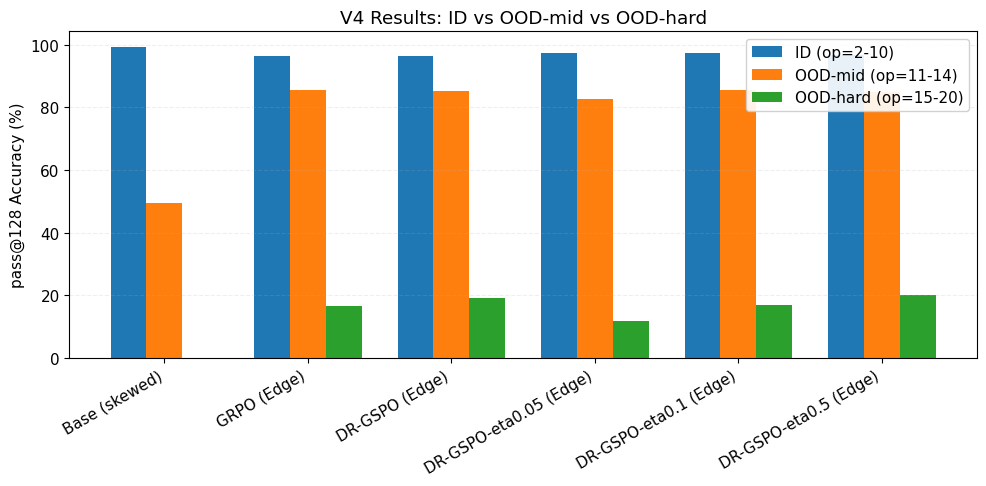

In [18]:
# Bar chart: pass@128 comparison
runs_done = [r for r in V4_RUNS if r in v4_data]
groups = ["ID (op=2-10)", "OOD-mid (op=11-14)", "OOD-hard (op=15-20)"]
labels = [DISPLAY_NAMES.get(r, r) for r in runs_done]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(runs_done))
width = 0.25

for i, group in enumerate(groups):
    vals = [v4_data[r][group][128] * 100 for r in runs_done]
    ax.bar(x + (i - 1) * width, vals, width, label=group)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("pass@128 Accuracy (%)")
ax.set_title("V4 Results: ID vs OOD-mid vs OOD-hard")
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(True, alpha=0.2, axis="y", linestyle="--")
fig.tight_layout()
fig.savefig("figures/v4_bar_comparison.png", dpi=200, bbox_inches="tight")
plt.show()